<a href="https://colab.research.google.com/github/kalashjain9/Python-Notes/blob/main/Python_Notes_Day_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

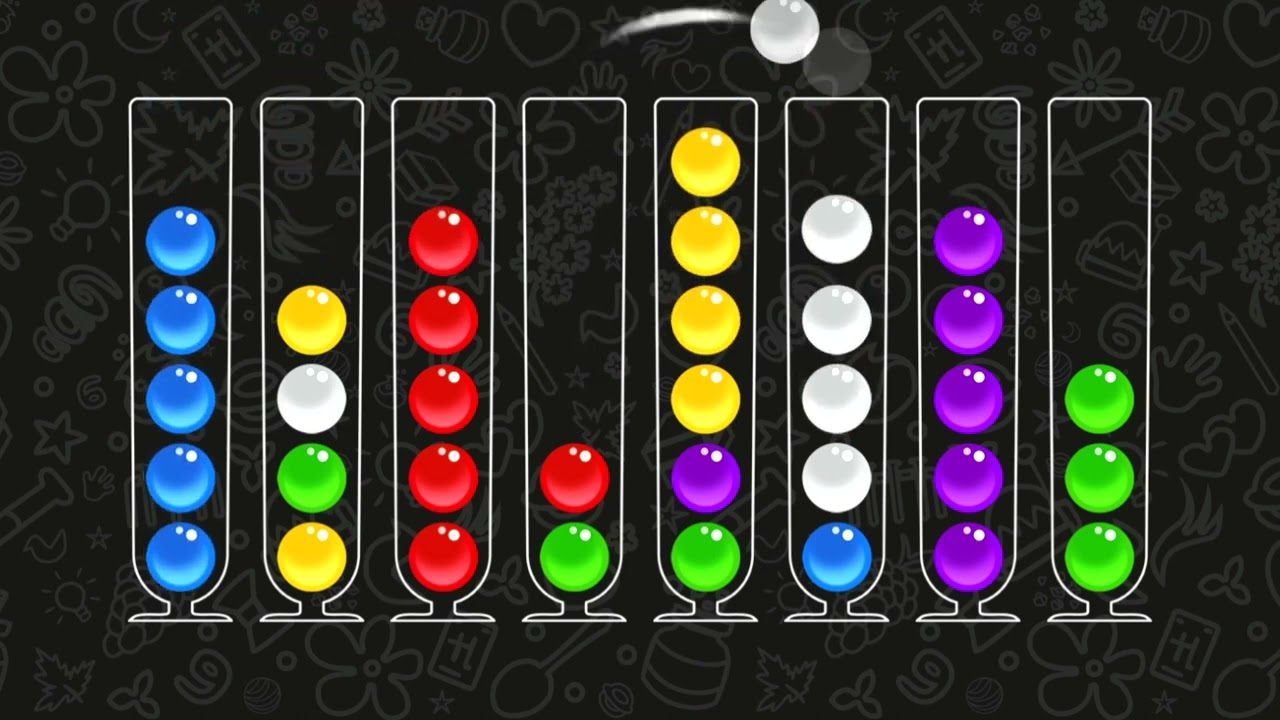


## How Decision Trees Work

### Theory

A **Decision Tree** is a supervised learning algorithm used for both classification and regression tasks. It works by **splitting the dataset** into smaller and smaller subsets based on feature values, forming a tree structure of decisions. Each node represents a decision based on a feature, and each leaf node represents an output (label or value).

The tree is built by recursively choosing the "best" feature to split the data at each step, which maximizes some **purity metric** (like Gini Impurity or Information Gain). The process continues until:
- A stopping condition is met (e.g., max depth),
- The node is pure (all samples have the same label),
- Or there are too few samples to split further.

**Advantages:**
- Easy to understand and interpret
- Handles both numerical and categorical data
- Requires minimal data preprocessing

**Common misunderstandings:**
- Decision trees don’t automatically handle categorical variables — **encoding is necessary**
- Trees tend to **overfit** if not pruned or regularized


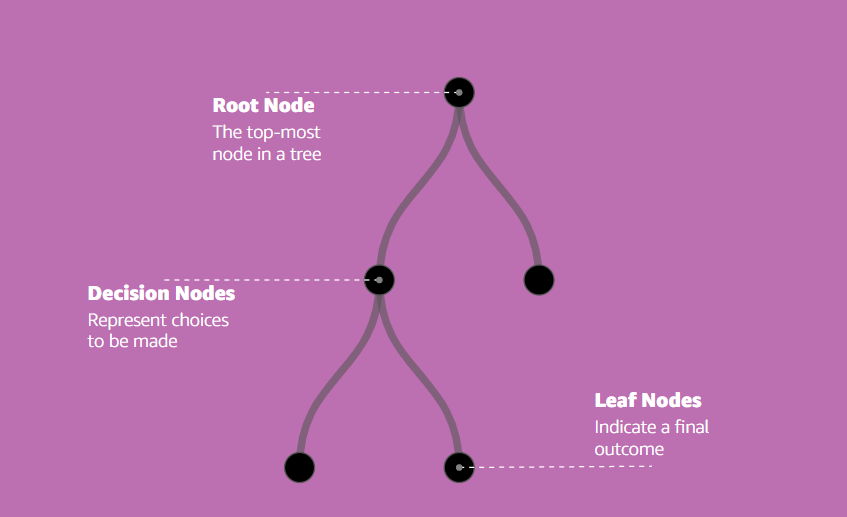

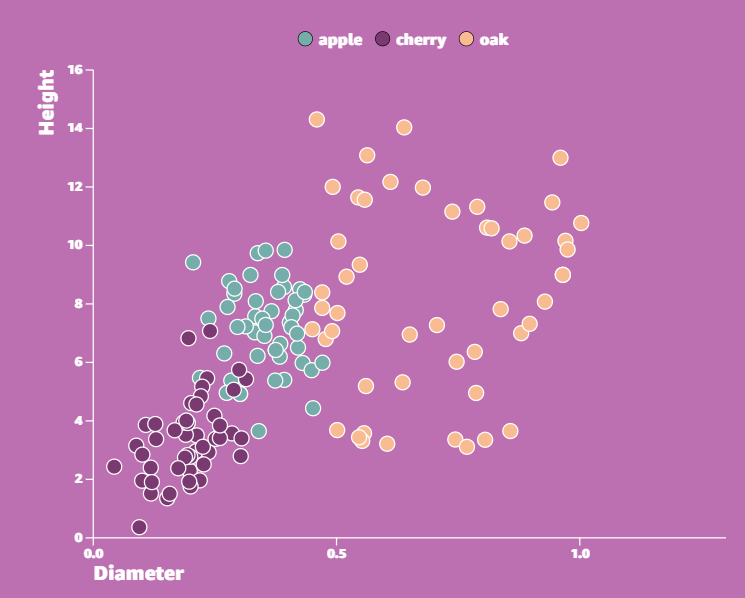

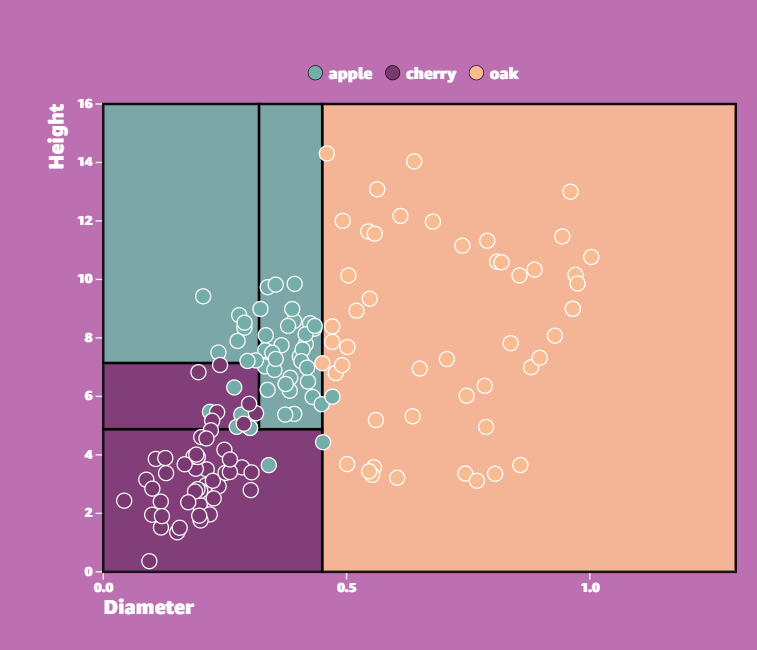

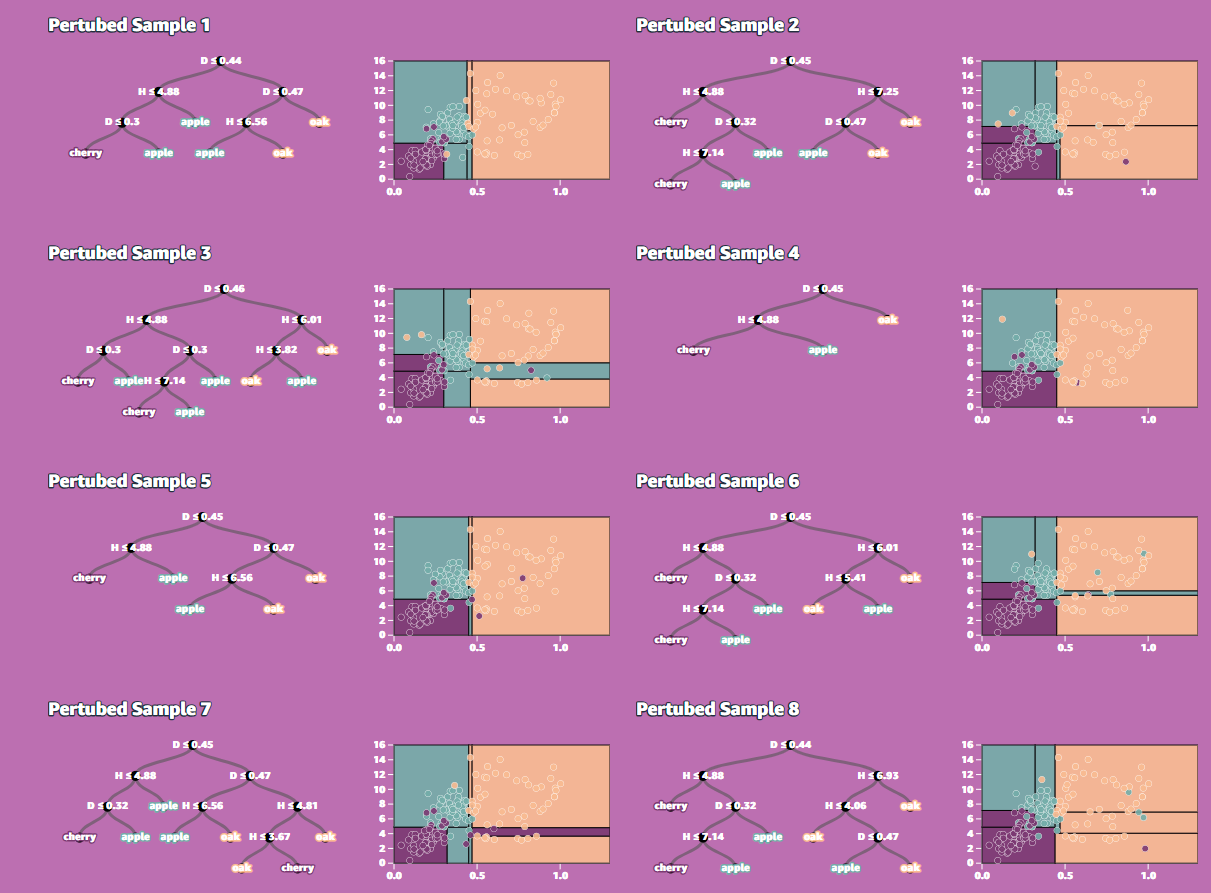

## Splitting Criteria: Gini Impurity

### Theory

**Gini impurity** is a measure of how often a randomly chosen element would be incorrectly labeled if randomly labeled according to the distribution of labels in the node.

**Basically it checks how impure [messy] the data is.**

A Gini Impurity of:
- **0** = perfectly pure node (only one class)
- **> 0** = mix of classes (impure)

It is calculated as:
```math
Gini = 1 - ∑(p_i^2)
```
where \( p_i \) is the probability of class i in the node.

Scikit-learn uses Gini Impurity by default in `DecisionTreeClassifier`.



## Implementation: DecisionTreeClassifier

### Example


In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_iris(return_X_y=True)

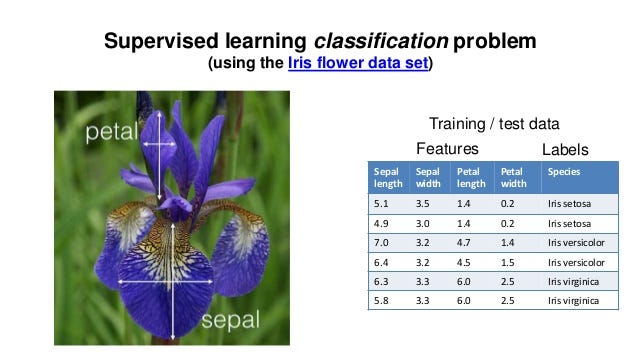

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


## Encoding

### Theory

Decision trees in scikit-learn **require numerical features**. Thus, any **categorical features** (like gender, country, etc.) need to be encoded before training.

There are two common encoding methods:

1. **Label Encoding** – Converts each category to a unique integer.
   - Works well when categories have ordinal meaning.
   - Can mislead the model if used on unordered categories.

2. **One-Hot Encoding** – Creates a binary column for each category.
   - Safer for unordered categories (e.g., city, color)
   - Increases feature space


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Sample dataset
df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red'],
    'Some Feature': [1, 0, 1, 0]
})
df

,Color,Some Feature
0,Red,1
1,Blue,0
2,Green,1
3,Red,0


In [ ]:

# Label Encoding
le = LabelEncoder()
df['Color_LabelEncoded'] = le.fit_transform(df['Color'])

# One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=['Color'])

print(df)
print(df_onehot)


   Color  Some Feature  Color_LabelEncoded
0    Red             1                   2
1   Blue             0                   0
2  Green             1                   1
3    Red             0                   2
   Some Feature  Color_LabelEncoded  Color_Blue  Color_Green  Color_Red
0             1                   2       False        False       True
1             0                   0        True        False      False
2             1                   1       False         True      False
3             0                   2       False        False       True


## Debugging Quiz

### ❓ What's wrong with this code?


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

df = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Male', 'Female'],
    'Label': [1, 0, 2, 0]
})

clf = DecisionTreeClassifier()

clf.fit(df[['Gender']], df['Label'])

ValueError: could not convert string to float: 'Male'

# Model Evaluation
## Accuracy, Precision, Recall, F1 Score
### Theory

After training a machine learning model, we need to evaluate **how well it performs**. In classification problems, we typically use the following metrics:


### 1. Accuracy

Accuracy is the **ratio of correct predictions** to the total predictions made.

```math
Accuracy = (TP + TN) / (TP + TN + FP + FN)
```

Good when:
- Classes are balanced
- All types of errors are equally important


### 2. Precision

Precision tells us how many of the **positive predictions were actually correct**.

```math
Precision = TP / (TP + FP)
```

Useful when:
- **False Positives** are costly (e.g., email spam filter)


### 3. Recall

Recall tells us how many of the **actual positives were correctly predicted**.

```math
Recall = TP / (TP + FN)
```

Useful when:
- **False Negatives** are costly (e.g., cancer detection)


## Precision vs Recall
### Precision:
**"Of all images predicted as Dogs, how many were actually Dogs?"**

### Recall:
**“Of all actual Dogs, how many did the model catch?”**

### 4. F1 Score

The harmonic mean of precision and recall. It balances the trade-off between the two.

```math
F1 = 2 * (Precision * Recall) / (Precision + Recall)
```

Good for:
- Imbalanced datasets
- When we care equally about FP and FN


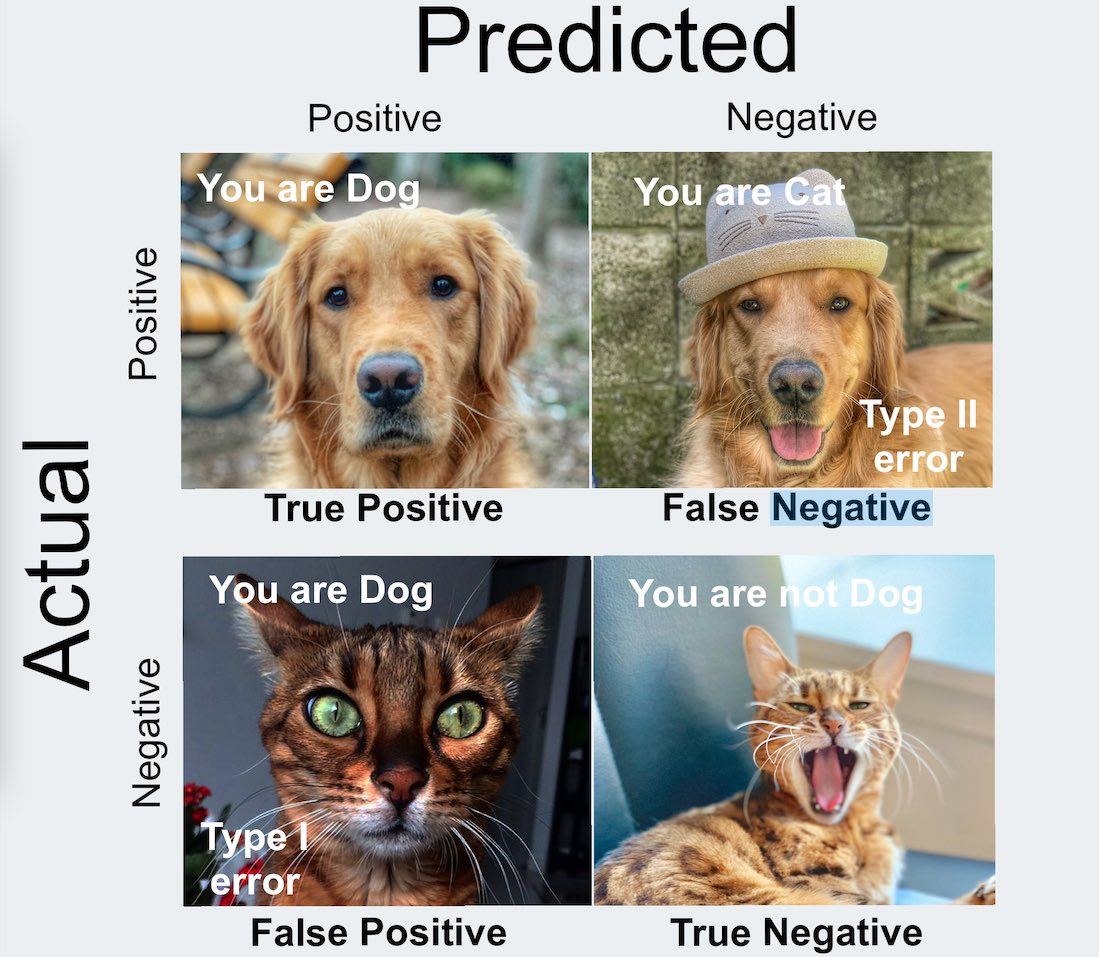

## ROC Curve and AUC

### Theory

The **ROC (Receiver Operating Characteristic) Curve** plots the **True Positive Rate (Recall)** against the **False Positive Rate** at various thresholds.

- A model that randomly guesses will be near the diagonal line
- A good model curves toward the top-left
- The **Area Under the Curve (AUC)** summarizes this performance:
  - 1.0 = perfect
  - 0.5 = random guessing



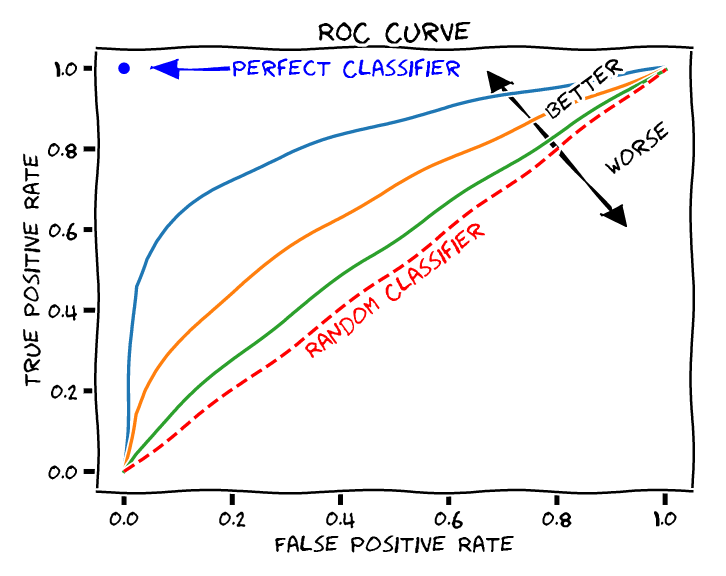

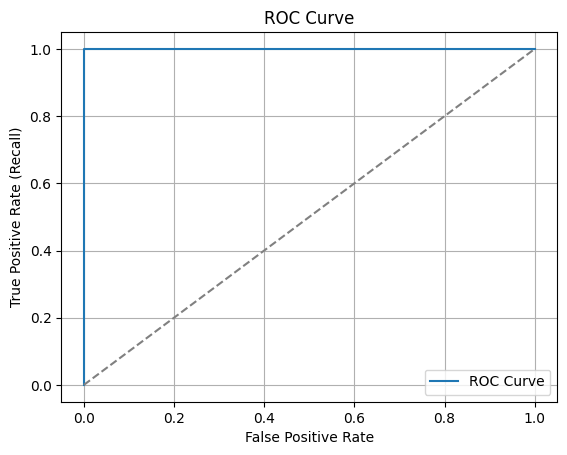

AUC: 1.0


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability estimates
y_score = clf.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# Plotting
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# AUC Score
print("AUC:", roc_auc_score(y_test, y_score))


# ***Thank U***

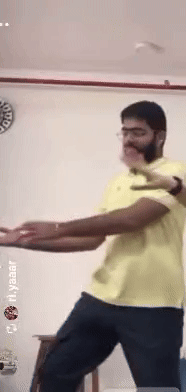

## **The Final Project (13th–15th July)**

### **Car Price Prediction Challenge**
[Car Price Prediction Dataset on Kaggle](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge)

#### Steps:
- **Load data**: `pd.read_csv()`
- **Clean/preprocess**: Handle missing values, encode categoricals.
- **Explore data**: Visualizations, statistics.
- **Feature engineering**: Create new features if needed.
- **Train models**: Linear Regression, Decision Tree.
- **Evaluate models**: Accuracy, confusion matrix, ROC.
- **Save results**: Export predictions.
- **Present findings**: Summarize insights, visualizations.

**Note - You'll have to explain your work on 16th's meeting**
**SUBMIT ON 15th - 5pm**

